**<h3>Teoretiska frågor</h3>**

__1.	Beskriv kort hur en relationsdatabas fungerar.__<br>
En relationsdatabas sparar data i tabeller som består av rader samt kolumner.  
Tabellerna är kopplade till varandra genom nycklar.  
Två vanligt förekommande nycklar är PK (Primary Key) eller FK (Foreign Key).


__2.	Vad menas med ’’CRUD’’-flödet?__<br>
CRUD är en modell som beskriver de fyra grundläggande aktiviteter för att hantera data i en databas.  


Create = lägga till rader i en tabell.<br>
Read = läsa ut data från en tabell.<br>
Update = uppdatera existerande data i en tabell.<br>
Delete = ta bort rader i en tabell.<br>


__3.	Beskriv kort vad en left join och en inner join är. Varför använder man det?__<br>
En left join väljer all data från raderna på den vänstra tabellen samt matchande rader från den högra.  
Inner join väljer matchande data på både vänster och höger tabell.
Joins används för att sammanfoga data från olika tabeller.

__4.	Beskriv kort vad indexering i SQL innebär.__<br>
Indexering används för att direkt söka bland sparade värden i ett index och därmed snabbt hittar de rader som matchar sökningen.  
Utan indexering så måste systemet gå rad för rad igenom tabellen, vilket då är slöare.

__5.	Beskriv kort vad en vy i SQL är.__<br>
En vy är en virtuell tabell där innehållet defineras av en query.  
Den är bra att använda när man behöver utföra samma komplexa queries eller vill kontrollera vad användarna kan se och ha åtkomst till i databasen. 

__6.	Beskriv kort vad en lagrad prodecur i SQL är.__<br>
En lagrad procedur är en sparad query (sparad i databasen).  
Den fungerar som en funktion eller metod som kan återanvändas. 



**<h3>Adventure Works</h3>**

AdventureWorks2022 är en relationsdatabas skapad av Microsoft i utbildningssyfte.  
Här finns data lagrad för ett fiktivt företag som tillverkar cyklar och dess tillbehör.  
Deras försäljningar är lagrade för åren 2011 till 2014.  
Databasen är organiserad i schemas som bl.a Sales, Human Resources, Person och Production.  


                    -
                    

Jag laddar in nödvändiga bibliotek för min programmeringsuppgift och ansluter till databasen genom en lokal SQL server.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect
from sqlalchemy.engine import URL
import pyodbc
from scipy.stats import sem, t


In [2]:
SERVER = 'localhost'
DATABASE = 'AdventureWorks2022'

connection_string = f'DRIVER={{ODBC Driver 18 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes;Encrypt=no'
connection_url = URL.create('mssql+pyodbc', query={'odbc_connect': connection_string})
engine = create_engine(connection_url)
connection = engine.connect()

Koden nedan visar schemas och antal tabeller databasen har. Jag har inte inkluderat systemrelaterade schemas då det innehåller metadata och är inte användbar för detta. Jag exekverar med Pandas.

In [3]:
query = """
    SELECT 
    TABLE_SCHEMA AS SchNamn, 
    COUNT(*) AS 'Tabeller'
    FROM 
    information_schema.tables
    WHERE 
    TABLE_SCHEMA NOT IN ('information_schema', 'sys')
    GROUP BY 
    TABLE_SCHEMA;
"""
schema_df = pd.read_sql_query(query, engine)
schema_df


,SchNamn,Tabeller
0,Sales,26
1,Person,15
2,Production,28
3,dbo,4
4,HumanResources,12
5,Purchasing,7


Här vill jag få veta hur många kunder finns. Jag har då hämtat datan från Sales.Customer tabellen.

In [4]:
query = """
SELECT COUNT(*) AS 'Antal Kunder' 
FROM Sales.Customer;
"""

kunder = pd.read_sql_query(query, engine)
print(kunder)

   Antal Kunder
0         19820


Här ser jag hur många anställda finns.

In [5]:
query = """
SELECT COUNT(*) AS 'Antal Anställda' 
FROM HumanResources.Employee;
"""

anställda = pd.read_sql_query(query, engine)
print(anställda)

   Antal Anställda
0              290


Jag vill kika mer på kolumner som finns för Employee i HR tabellen.

In [6]:
query = """
SELECT COLUMN_NAME
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_NAME = 'Employee' AND TABLE_SCHEMA = 'HumanResources';
"""

columns = pd.read_sql_query(query, engine)
print(columns)

          COLUMN_NAME
0    BusinessEntityID
1    NationalIDNumber
2             LoginID
3    OrganizationNode
4   OrganizationLevel
5            JobTitle
6           BirthDate
7       MaritalStatus
8              Gender
9            HireDate
10       SalariedFlag
11      VacationHours
12     SickLeaveHours
13        CurrentFlag
14            rowguid
15       ModifiedDate


Här kan jag se vilka roller finns för anställda.

In [7]:
query = """
SELECT 
JobTitle AS Roll,
COUNT(*) AS Antal
FROM 
HumanResources.Employee
GROUP BY 
JobTitle
ORDER BY 
Antal DESC;
"""

roles = pd.read_sql_query(query, engine)
print(roles)

                                 Roll  Antal
0        Production Technician - WC50     26
1        Production Technician - WC60     26
2        Production Technician - WC40     26
3        Production Technician - WC30     25
4        Production Technician - WC20     22
..                                ...    ...
62             Senior Design Engineer      1
63  Shipping and Receiving Supervisor      1
64      Vice President of Engineering      1
65       Vice President of Production      1
66            Vice President of Sales      1

[67 rows x 2 columns]


Jag vill kolla på det totala antalet försäljningar för varje år i databasen. försäljningarna är grupperade per år och åren sorteras i stigande ordning.

In [8]:
query = """
SELECT 
YEAR(OrderDate) AS År,
COUNT(*) AS Sales
FROM 
Sales.SalesOrderHeader
GROUP BY 
YEAR(OrderDate)
ORDER BY 
År;
"""

sales_år = pd.read_sql_query(query, engine)
print(sales_år)

     År  Sales
0  2011   1607
1  2012   3915
2  2013  14182
3  2014  11761


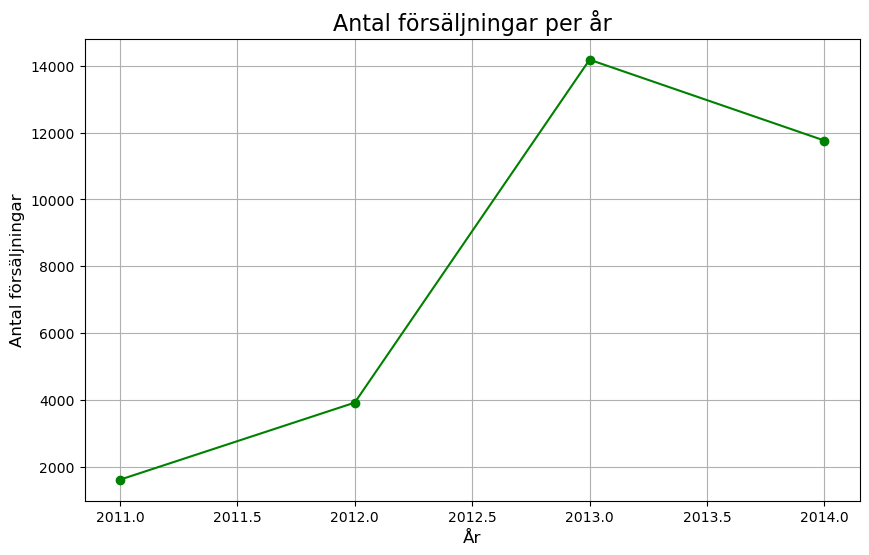

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(sales_år['År'], sales_år['Sales'], marker='o', color='green')
plt.title('Antal försäljningar per år', fontsize=16)
plt.xlabel('År', fontsize=12)
plt.ylabel('Antal försäljningar', fontsize=12)
plt.grid(True)
plt.show()

Här näst vill jag se vilka kolumner finns i Production.Product tabellen.

In [10]:
query = """
SELECT COLUMN_NAME
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_SCHEMA = 'Production' AND TABLE_NAME = 'Product';
"""

kolumner_products = pd.read_sql_query(query, engine)
print(kolumner_products)

              COLUMN_NAME
0               ProductID
1                    Name
2           ProductNumber
3                MakeFlag
4       FinishedGoodsFlag
5                   Color
6        SafetyStockLevel
7            ReorderPoint
8            StandardCost
9               ListPrice
10                   Size
11    SizeUnitMeasureCode
12  WeightUnitMeasureCode
13                 Weight
14      DaysToManufacture
15            ProductLine
16                  Class
17                  Style
18   ProductSubcategoryID
19         ProductModelID
20          SellStartDate
21            SellEndDate
22       DiscontinuedDate
23                rowguid
24           ModifiedDate


Här har jag hämtat produktnamn och ID på deras varor, för att se vilka produkter såldes mest under 2014.  
Jag skapar inner joins för att länka försäljningsrader till produktinformation, ProductID, också för att använda information som orderdatum.

In [11]:
query = """
SELECT 
p.ProductID AS ID,
p.Name AS Produkt,
SUM(sod.OrderQty) AS Sålda

FROM 
Sales.SalesOrderDetail sod

INNER JOIN 
Production.Product p
ON sod.ProductID = p.ProductID

INNER JOIN 
Sales.SalesOrderHeader soh
ON sod.SalesOrderID = soh.SalesOrderID

WHERE 
YEAR(soh.OrderDate) = 2014

GROUP BY 
p.ProductID, p.Name

ORDER BY 
Sålda DESC;
"""

prodsales_2014 = pd.read_sql_query(query, engine)
print(prodsales_2014)

      ID                  Produkt  Sålda
0    870    Water Bottle - 30 oz.   2902
1    712             AWC Logo Cap   1950
2    711   Sport-100 Helmet, Blue   1776
3    873      Patch Kit/8 Patches   1761
4    707    Sport-100 Helmet, Red   1717
..   ...                      ...    ...
175  852        Women's Tights, S      2
176  763         Road-650 Red, 48      1
177  765       Road-650 Black, 58      1
178  726  LL Road Frame - Red, 48      1
179  730  LL Road Frame - Red, 62      1

[180 rows x 3 columns]


Jag vill nu se vad företagets toppkunder är. Jag skapar även en stapeldiagram för de 10 kunderna som har spenderat mest på företagets varor. Jag har även inverterat så att toppkunderna visas överest. Jag har kopplat tabellerna Sales.Customer med Person.Person för att få kundernas namn. 

In [12]:
query = """
SELECT 
C.CustomerID, 
P.FirstName + ' ' + P.LastName AS Namn, 
SUM(SOH.SubTotal) AS Spenderat

FROM 
Sales.SalesOrderHeader SOH

INNER JOIN 
Sales.Customer C ON SOH.CustomerID = C.CustomerID
INNER JOIN 
Person.Person P ON C.PersonID = P.BusinessEntityID

GROUP BY 
C.CustomerID, P.FirstName, P.LastName

ORDER BY 
Spenderat DESC
"""

topp_kunder = pd.read_sql_query(query, engine)
print(topp_kunder.head())

   CustomerID           Namn    Spenderat
0       29818    Roger Harui  877107.1923
1       29715   Andrew Dixon  853849.1795
2       29722    Reuben D'sa  841908.7707
3       30117   Robert Vessa  816755.5763
4       29614  Ryan Calafato  799277.8950


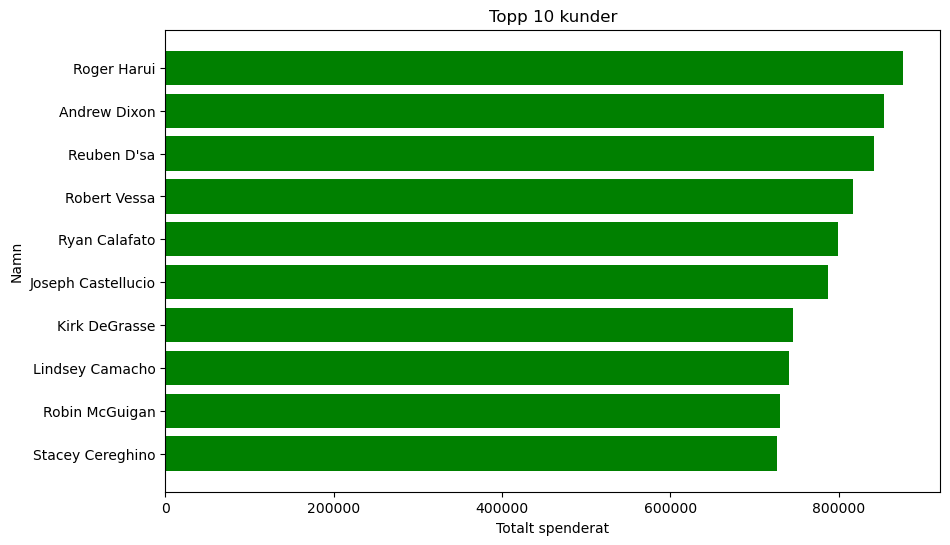

In [13]:
plt.figure(figsize=(10, 6))
plt.barh(topp_kunder["Namn"].head(10), topp_kunder["Spenderat"].head(10), color='green')
plt.xlabel("Totalt spenderat")
plt.ylabel("Namn")
plt.title("Topp 10 kunder")
plt.gca().invert_yaxis()
plt.show()

Nu vill jag analysera vilka produkter som köps mest av toppkunder. Jag använder mig av objektet topp_kunder för att bara inkludera dessa kunder. Jag hämtar produktdata för att summera köpta enheter och totalkostnaden för varje produkt. 

In [14]:
topp_kunder_ids = topp_kunder["CustomerID"].tolist()

query_produkter = f"""
SELECT 
C.CustomerID, 
P.FirstName + ' ' + P.LastName AS Namn, 
PR.Name AS Produkt, 
SUM(SOD.OrderQty) AS Antal, 
SUM(SOD.LineTotal) AS Totalbelopp

FROM 
Sales.SalesOrderHeader SOH
    
JOIN 
Sales.Customer C ON SOH.CustomerID = C.CustomerID
JOIN 
Person.Person P ON C.PersonID = P.BusinessEntityID
JOIN 
Sales.SalesOrderDetail SOD ON SOH.SalesOrderID = SOD.SalesOrderID
JOIN 
Production.Product PR ON SOD.ProductID = PR.ProductID

WHERE 
C.CustomerID IN ({', '.join(map(str, topp_kunder_ids))})

GROUP BY 
C.CustomerID, P.FirstName, P.LastName, PR.Name

ORDER BY 
Totalbelopp DESC
"""

topp_produkter = pd.read_sql_query(query_produkter, engine)
print(topp_produkter.head(10))

   CustomerID              Namn                  Produkt  Antal   Totalbelopp
0       29913     Anton Kirilov   Mountain-200 Black, 42     73  91916.578761
1       29818       Roger Harui   Mountain-200 Black, 38     68  86836.683325
2       29913     Anton Kirilov  Mountain-200 Silver, 42     65  83782.892851
3       29818       Roger Harui  Mountain-200 Silver, 46     63  82524.298260
4       29712     Holly Dickson   Mountain-200 Black, 38     63  80156.393876
5       29497  François Ferrier   Mountain-200 Black, 42     61  77477.419292
6       29497  François Ferrier  Mountain-200 Silver, 42     58  75093.933852
7       29580    Richard Bready   Mountain-200 Black, 46     58  74219.976420
8       29913     Anton Kirilov  Mountain-200 Silver, 46     56  74091.598624
9       29818       Roger Harui  Mountain-200 Silver, 38     56  73419.199308


Och här nedan kan vi då se en stapeldiagram för viktiga produkter.

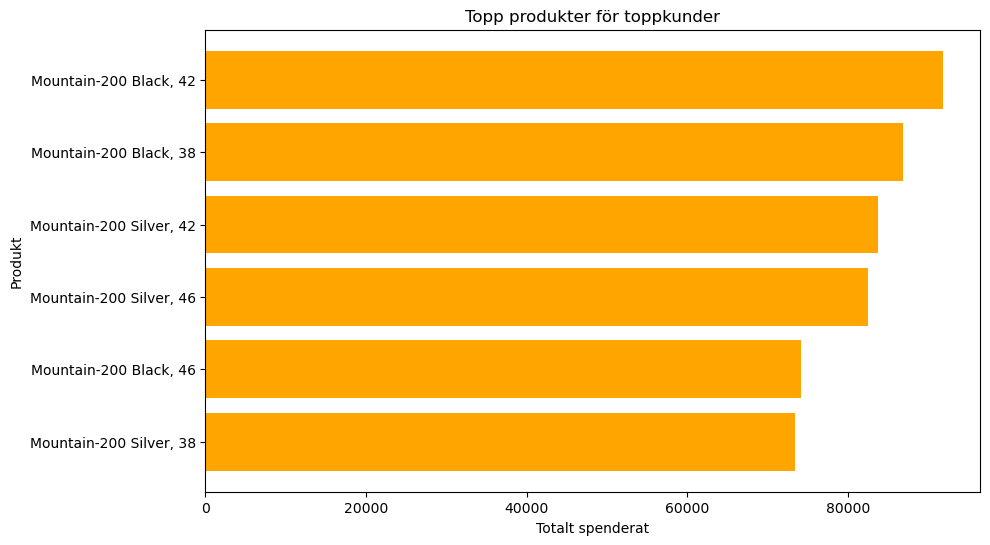

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(topp_produkter["Produkt"].head(10), topp_produkter["Totalbelopp"].head(10), color='orange')
plt.xlabel("Totalt spenderat")
plt.ylabel("Produkt")
plt.title("Topp produkter för toppkunder")
plt.gca().invert_yaxis()
plt.show()

Här nedan har jag gjort en statistik uppskattning av det genomsnittliga spenderandet och säkerhetsgränserna för detta genomsnitt. 
Jag hämtar in totalbelopp från topp_produkter som då innehåller summan av kostnaden för produkter köpta av toppkunder.
Jag räknar först ut medelvärdet av totalbelopp. Sen beräknar jag ett konfidensintervall baserat på t-fördelningen.

Konfidensnivå på 95 percent då det är standard. df är frihetsgrader, och så har vi medelv'rdet av data med standradfelet på scale. vi får sedan ett tuple med lägre och övre gräns för konfidensintervallet.

In [16]:
data = topp_produkter["Totalbelopp"]

mean = np.mean(data)
conf_interval = t.interval(0.95, df=len(data)-1, loc=mean, scale=sem(data))

print(f"Medelvärde: {mean:.2f}")
print(f"95% konfidensintervall: ({conf_interval[0]:.2f}, {conf_interval[1]:.2f})")

Medelvärde: 1382.88
95% konfidensintervall: (1353.74, 1412.02)
